In [43]:
!pip install optuna-integration

In [44]:
import os

mediu_sw_calcul='jax' # "jax" sau "tensorflow" sau "torch"
os.environ["KERAS_BACKEND"] = mediu_sw_calcul  # @param ["tensorflow", "jax", "torch"]

import keras
from keras import layers
from keras import ops
import jax.numpy as jnp

import numpy as np
import tensorflow as tf
import optuna
import optuna.visualization as vis
import requests
from tensorflow.keras import layers, models

import time

# Global Settings
BATCH_SIZE = [32,64,128]
NUM_TRIALS = 40
EPOCHS= 100
# NUM_CLASSES = 10
# INPUT_SHAPE = (28, 28, 1) # MNIST shape



# DATA LOADING 
### Dimensiunile imaginilor afecteaza parametrul 'patch_size' al modelului ViT. Ca totul sa fie in regula 'patch_size' trebuie sa divida dimensiunea imaginii. De exemplu, in cazul setului de date 'mnist' o imaginea are dimensiunea 28x28, deci 'patch_size' divide 28 ( [2, 4, 7] )

In [45]:
# --- CONFIGURARE DATASET ---
# Opțiuni: "mnist", "fashion_mnist", "cifar10", "cifar100"
SELECTED_DATASET = "cifar10"

def load_data_universal(dataset_name):
    if dataset_name == "mnist":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        channels = 1
    elif dataset_name == "fashion_mnist":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
        channels = 1
    elif dataset_name == "cifar10":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
        channels = 3
    elif dataset_name == "cifar100":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
        channels = 3

    # Update Global Settings (Importat pentru model)
    global INPUT_SHAPE, NUM_CLASSES
    INPUT_SHAPE = (x_train.shape[1], x_train.shape[2], channels)
    NUM_CLASSES = len(np.unique(y_train))

    # Preprocesare (Standardizarea Z)
    x_train = x_train.astype("float32")
    x_test = x_test.astype("float32")

    # Calculăm media și deviația standard pe setul de antrenare
    # mean = np.mean(x_train, axis=(0, 1, 2), keepdims=True)
    # std = np.std(x_train, axis=(0, 1, 2), keepdims=True)
    mean = np.mean(x_train)
    std = np.std(x_train)

    # Aplicăm formula: (x - medie) / std
    x_train = (x_train - mean) / (std + 1e-7)
    x_test = (x_test - mean) / (std + 1e-7) 

    if channels == 1:
        # Adăugăm dimensiunea pentru canal (28, 28) -> (28, 28, 1)
        x_train = np.expand_dims(x_train, -1)
        x_test = np.expand_dims(x_test, -1)

    y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
    y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

    print(f'Input shape:{INPUT_SHAPE}')
    print(f'Number of classes:{NUM_CLASSES}')
    print(f"Data ready: {x_train.shape}")
    return (x_train, y_train), (x_test, y_test)
(x_train, y_train), (x_test, y_test) = load_data_universal(SELECTED_DATASET)

Input shape:(32, 32, 3)
Number of classes:10
Data ready: (50000, 32, 32, 3)


In [46]:
# import keras
# from keras import layers

# def get_augmentation_layers():
#     return keras.Sequential([
#         layers.RandomFlip("horizontal"), # Răsturnare oglindită
#         layers.RandomRotation(0.1),      # Rotire ușoară (10%)
#         layers.RandomZoom(0.1),          # Zoom ușor
#         layers.RandomContrast(0.2) # Variază contrastul cu 20%
#     ], name="augmentation")

In [47]:
try:
    from keras import ops
    
    # ops.convert_to_tensor este polimorfic: 
    # - returnează jax.Array dacă backend-ul e JAX
    # - returnează tf.Tensor dacă backend-ul e TF
    x_train = ops.convert_to_tensor(x_train)
    y_train = ops.convert_to_tensor(y_train)
    x_test = ops.convert_to_tensor(x_test)
    y_test = ops.convert_to_tensor(y_test)
    
    print(f"Datele au fost convertite automat pentru backend-ul: {keras.backend.backend()}")
except Exception as e:
    # Dacă conversia eșuează rămânem la NumPy (care funcționează oricum)
    print(f"Rămânem la formatul NumPy. Detalii: {e}")


# def create_augmented_dataset(x, y, factor=2):
#     """
#     factor: de câte ori să multiplicăm setul de date (ex: 2 înseamnă dublare)
#     """
#     x_aug_list = [x]
#     y_aug_list = [y]
    
#     # Folosim straturile de augmentare Keras pe CPU
#     aug_layer = get_augmentation_layers()
    
#     print(f"Generăm augmentarea (factor {factor})...")
#     for i in range(factor - 1):
#         # Aplicăm augmentarea pe tot setul (Keras 3 rulează asta eficient)
#         x_new = aug_layer(x, training=True)
#         x_aug_list.append(x_new)
#         y_aug_list.append(y)
    
#     # Concatenăm totul într-un singur array NumPy mare
#     x_final = np.concatenate([np.array(img) for img in x_aug_list], axis=0)
#     y_final = np.concatenate(y_aug_list, axis=0)
    
#     return x_final, y_final

# # --- PROCESUL TĂU ---
# # 1. Încarci și standardizezi Z
# (x_train, y_train), (x_test, y_test) = load_data_universal(SELECTED_DATASET)

# # 2. Augmentezi datele în RAM (CPU)
# if SELECTED_DATASET == "cifar10":
#     x_train, y_train = create_augmented_dataset(x_train, y_train, factor=2)

# # 3. Trimiti datele finale (deja augmentate) pe GPU pentru JAX
# try:
#     x_train = ops.convert_to_tensor(x_train)
#     y_train = ops.convert_to_tensor(y_train)
#     x_test = ops.convert_to_tensor(x_test)
#     y_test = ops.convert_to_tensor(y_test)
#     print("Datele augmentate sunt acum pe GPU.")
# except Exception as e:
#     print(f"Eroare conversie: {e}")



# print(f"Data ready: {x_train.shape}")

Datele au fost convertite automat pentru backend-ul: jax


In [48]:
# data_augmentation = get_augmentation_layers()

# MODELS

## 1. HVTINY
### https://github.com/radu-dogaru/hvtiny/blob/main/A_comparison_of_tiny_ml_skin_cancer_2025_reprint.pdf


In [49]:
# Load HVTINY from source
# if SELECTED_DATASET == "cifar10":
#   url = "https://raw.githubusercontent.com/radu-dogaru/hvtiny/refs/heads/main/hvtiny_cat_aug.py"
#   #data_augmentation = get_augmentation_layers()
# else:
url = "https://raw.githubusercontent.com/radu-dogaru/hvtiny/refs/heads/main/hvtiny_cat.py"
response = requests.get(url)
if response.status_code == 200:
    exec(response.text)
    print("HVTINY implementation loaded.")
else:
    print("Error loading HVTINY.")

HVTINY implementation loaded.


## 1.1 HVTINY - OPTUNA

In [50]:
def objective_HVTINY(trial):
    # profil_map = {
    #     "ramp_up": (1, 2, 2, 4),
    #     "wide_mid": (1, 4, 4, 2),
    #     "standard": (1, 4, 2, 1)
    # }
    profil_map = {
        "simplu": (1, 2, 2, 1),
        "complex": (1, 4, 2, 1)
    }
    # 1. Define the Search Space (The "Architecture" part of NAS)
    # We let Optuna choose key HVTINY parameters
    my_k = trial.suggest_int('k', 15, 60, step=5)
    my_drp = trial.suggest_float('dropout', 0.1, 0.5)
    nl_top = trial.suggest_int('nl_top', 1, 4)
    nl_bot = trial.suggest_int('nl_bot', 1, 2)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size",BATCH_SIZE)
    # profil_key = trial.suggest_categorical("profil", ["ramp_up", "wide_mid", "standard"])
    profil_key = trial.suggest_categorical("profil", ["simplu", "complex"])
    profil_choice = profil_map[profil_key]

    # 2. Build the Model
    model = hvtiny(
        INPUT_SHAPE, 
        num_classes=NUM_CLASSES, 
        flat=0, 
        hid=True, 
        profil=profil_choice ,    #(1, 4, 2, 1) ,    #profil_choice, 
        k=my_k, 
        nl=(nl_top, nl_bot), 
        scale=False, 
        drop=my_drp, 
        lr=lr
    )
    
    # 3. Quick Train
    # We use few epochs for the search to keep it fast
    optimizator_trial = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizator_trial,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    # Acesta raportează acuratețea către Optuna după fiecare epocă
    pruning_callback = optuna.integration.TFKerasPruningCallback(trial, "val_accuracy")
    
    history = model.fit(
        x_train, y_train, 
        validation_split=0.1, 
        epochs=10, 
        batch_size=batch_size, 
        callbacks=[pruning_callback],
        verbose=0
    )
    
    # 4. Return Accuracy
    val_acc = max(history.history['val_accuracy'])
    return val_acc

In [51]:
start_time_HVTINY_optuna = time.perf_counter()

study_HVTINY = optuna.create_study(direction='maximize')
study_HVTINY.optimize(objective_HVTINY, n_trials=NUM_TRIALS) # Change to 50+ for real research

end_time_HVTINY_optuna = time.perf_counter()
time_HVTINY_optuna = end_time_HVTINY_optuna - start_time_HVTINY_optuna

# print("--- NAS Results ---")
# print(f"Best Accuracy: {study_HVTINY.best_value:.4f}")
# print("Best Params:", study_HVTINY.best_params)
# print(f"Time: {time_HVTINY_optuna:.2f}s")

print("--- Rezultate NAS ---")
print(f"Cea mai buna acuratete: {study_HVTINY.best_value:.4f}")
print("Cei mai buni paramatri gasiti:", study_HVTINY.best_params)
print(f"Timpul necesar cautarii: {(time_HVTINY_optuna/60):.2f}min")
best_params_HVTINY = study_HVTINY.best_params
for key, value in best_params_HVTINY.items():
    print(f'{key} : {value}')

[I 2026-05-19 18:16:49,169] A new study created in memory with name: no-name-acb13eca-2656-4db1-a2c3-841a9cdd42e8


Profil:  (1, 2, 2, 1)
adding
adding
adding
adding


[I 2026-05-19 18:18:44,631] Trial 0 finished with value: 0.5940000414848328 and parameters: {'k': 60, 'dropout': 0.4068487049139442, 'nl_top': 4, 'nl_bot': 2, 'lr': 0.00047803254211539644, 'batch_size': 64, 'profil': 'simplu'}. Best is trial 0 with value: 0.5940000414848328.


Profil:  (1, 4, 2, 1)
adding
adding
adding
adding


[I 2026-05-19 18:20:23,034] Trial 1 finished with value: 0.48500001430511475 and parameters: {'k': 35, 'dropout': 0.1010190678056568, 'nl_top': 4, 'nl_bot': 1, 'lr': 0.003852715826013169, 'batch_size': 64, 'profil': 'complex'}. Best is trial 0 with value: 0.5940000414848328.


...

Profil:  (1, 4, 2, 1)
adding


[I 2026-05-19 18:53:03,226] Trial 38 pruned. Trial was pruned at epoch 0.


Profil:  (1, 4, 2, 1)
adding


[I 2026-05-19 18:54:12,032] Trial 39 finished with value: 0.7676000595092773 and parameters: {'k': 55, 'dropout': 0.26313099323898526, 'nl_top': 1, 'nl_bot': 1, 'lr': 0.005010457358386217, 'batch_size': 64, 'profil': 'complex'}. Best is trial 35 with value: 0.7838000655174255.


--- Rezultate NAS ---
Cea mai buna acuratete: 0.7838
Cei mai buni paramatri gasiti: {'k': 55, 'dropout': 0.26151041839558853, 'nl_top': 1, 'nl_bot': 1, 'lr': 0.005084062333854341, 'batch_size': 64, 'profil': 'complex'}
Timpul necesar cautarii: 37.38min
k : 55
dropout : 0.26151041839558853
nl_top : 1
nl_bot : 1
lr : 0.005084062333854341
batch_size : 64
profil : complex


### Vizualizarea procesului de cautare

In [52]:
# # Afișează evoluția scorului
fig = vis.plot_optimization_history(study_HVTINY)
fig.show()

# # Vezi care parametri contează cel mai mult
# vis.plot_param_importances(study_HVTINY)

# # Vizualizează corelațiile dintre parametri
# vis.plot_parallel_coordinate(study_HVTINY)

In [55]:
# Re-definim maparea pentru reconstrucție
# profil_map = {
#     "ramp_up": (1, 2, 2, 4),
#     "wide_mid": (1, 4, 4, 2),
#     "standard": (1, 4, 2, 1)
# }
profil_map = {
        "simplu": (1, 2, 2, 1),
        "complex": (1, 4, 2, 1)
    }
final_profil = profil_map[best_params_HVTINY['profil']]

# Build the 'Optimized' model
model_HVTINY = hvtiny(
    INPUT_SHAPE, 
    num_classes=NUM_CLASSES,
    flat=0, 
    hid=True, 
    profil= final_profil, #(1, 4, 2, 1),    #final_profil,
    k=best_params_HVTINY['k'],
    nl=(best_params_HVTINY['nl_top'], best_params_HVTINY['nl_bot']),
    drop=best_params_HVTINY['dropout'],
    lr=best_params_HVTINY['lr']
)
model_HVTINY.summary()

Profil:  (1, 4, 2, 1)
adding


Model: "functional_164"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_5327CLONE          │ (None, 32, 32, 3)      │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_139 (Conv2D)             │ (None, 32, 32, 55)     │         1,540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_441 (ReLU)                │ (None, 32, 32, 55)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_441            │ (None, 32, 32, 55)     │           550 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_556               │ (None, 16, 16, 55)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_917 (Dropout)           │ (None, 16, 16, 55)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_417            │ (None, 16, 16, 220)    │        12,815 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_442 (ReLU)                │ (None, 16, 16, 220)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_442            │ (None, 16, 16, 220)    │         2,200 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_557               │ (None, 8, 8, 220)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_918 (Dropout)           │ (None, 8, 8, 220)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_418            │ (None, 8, 8, 110)      │        26,290 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_558               │ (None, 4, 4, 110)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_919 (Dropout)           │ (None, 4, 4, 110)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_419            │ (None, 4, 4, 55)       │         7,095 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_559               │ (None, 2, 2, 55)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_920 (Dropout)           │ (None, 2, 2, 55)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_139    │ (None, 55)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_470 (Dense)               │ (None, 55)             │         3,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 54,350 (212.30 KB)

 Trainable params: 54,240 (211.88 KB)

 Non-trainable params: 110 (440.00 B)

## 1.2 Antrenare HVTINY 

In [56]:
optimizer_optimizat = keras.optimizers.Adam(learning_rate=best_params_HVTINY['lr'])
model_HVTINY.compile(optimizer=optimizer_optimizat, loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_filepath_hvtiny = 'best_hvtiny_model.keras'
model_checkpoint_callback_hvtiny = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath_hvtiny,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)
print("\nÎncepe antrenarea finală a modelului HVTINY optimizat...")
start_time_HVTINY_train = time.perf_counter()

history_hvtiny = model_HVTINY.fit(x_train,
                 y_train,
                 epochs=EPOCHS,
                 batch_size=best_params_HVTINY['batch_size'],
                 validation_data=(x_test, y_test),
                 callbacks=[model_checkpoint_callback_hvtiny],
                 verbose=1
                )
end_time_HVTINY_train = time.perf_counter()
time_HVTINY_train = end_time_HVTINY_train - start_time_HVTINY_train

print("Evaluzarea celui mai bun model pe setul de test:")
model_HVTINY.load_weights(checkpoint_filepath_hvtiny)
test_loss_hv, test_acc_hv = model_HVTINY.evaluate(x_test, y_test)

# print("--------------- Training Results --------------")
# print(f"\nFinal Performance on Test Set: {test_acc_hv:.4f}")
# print(f"Time: {time_HVTINY_train:.2f}s")

print("--------------- Rezultate Antrenare --------------")
print(f"\nAcuratețea finală după antrenarea completă: { test_acc_hv :.4f}")
print(f"Timpul de antrenare: {(time_HVTINY_train/60):.2f}min")



Începe antrenarea finală a modelului HVTINY optimizat...
Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.3046 - loss: 1.8282 - val_accuracy: 0.5059 - val_loss: 1.3603
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5235 - loss: 1.3124 - val_accuracy: 0.6015 - val_loss: 1.0854
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5959 - loss: 1.1307 - val_accuracy: 0.6639 - val_loss: 0.9634
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6425 - loss: 1.0244 - val_accuracy: 0.6936 - val_loss: 0.8541
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6769 - loss: 0.9319 - val_accuracy: 0.6991 - val_loss: 0.8449
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6972 - loss: 0.8889 - val_accuracy: 0.7221 - val_loss: 0.7861
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7148 - loss: 0.8404 - val_accuracy: 0.7346 - val_loss: 0.7705
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━

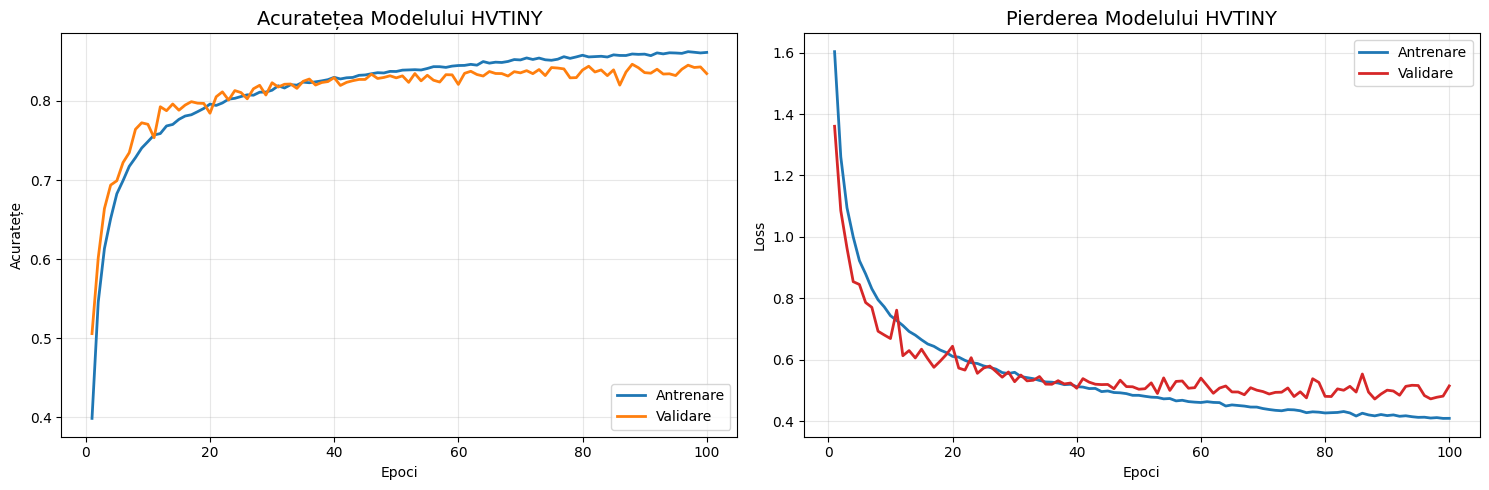

<Figure size 640x480 with 0 Axes>

In [57]:
import matplotlib.pyplot as plt
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Grafic pentru Acuratețe
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Antrenare', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validare', color='#ff7f0e', linewidth=2)
    plt.title('Acuratețea Modelului HVTINY', fontsize=14)
    plt.xlabel('Epoci')
    plt.ylabel('Acuratețe')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Grafic pentru Pierdere (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Antrenare', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validare', color='#d62728', linewidth=2)
    plt.title('Pierderea Modelului HVTINY', fontsize=14)
    plt.xlabel('Epoci')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.savefig('grafic_antrenare_hvtiny.png')

# Apelează funcția după ce fit() s-a terminat
plot_training_history(history_hvtiny)

## 2. ViT adaptat de pe Keras
#### https://keras.io/examples/vision/image_classification_with_vision_transformer/

In [58]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=ops.relu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = ops.shape(images)[0]
        patches = ops.image.extract_patches(images, self.patch_size)
        patch_dims = ops.shape(patches)[-1]
        patches = ops.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.arange(start=0, stop=self.num_patches, step=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded


In [59]:
def create_vit_nas(trial_params):
    patch_size = trial_params["patch_size"]
    num_patches = (INPUT_SHAPE[0] // patch_size) ** 2
    projection_dim = trial_params["projection_dim"]
    num_heads = trial_params["num_heads"]
    transformer_layers = trial_params["transformer_layers"]

    # Unitățile MLP sunt de obicei un multiplu al dimensiunii de proiecție
    transformer_units = [projection_dim * 2, projection_dim]

    inputs = keras.Input(shape=INPUT_SHAPE)
    # if SELECTED_DATASET == "cifar10":
    #    # augmentation = get_augmentation_layers()
    #     x = augmentation(inputs)
    # else:
    #   x= inputs


    # Create patches
    patches = Patches(patch_size)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Transformer blocks
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim // num_heads, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation) # Mai eficient decât Flatten pentru TinyML

    logits = layers.Dense(NUM_CLASSES, activation="softmax")(representation)

    model = keras.Model(inputs=inputs, outputs=logits)
    return model

## 2.1 VIT - OPTUNA

In [60]:
def objective_vit(trial):
    # Definirea spațiului de căutare
    # Atenție: heads trebuie să dividă projection_dim!
    projection_dim = trial.suggest_categorical("projection_dim", [16,32, 64]) # fara 32
    num_heads = trial.suggest_categorical("num_heads", [2, 4,8]) # 16 in loc de 4 
    # lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True) # 
    lr = trial.suggest_float("lr", 5e-5, 2e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size",BATCH_SIZE)
    
    if projection_dim % num_heads != 0:
        raise optuna.exceptions.TrialPruned()

    params = {
        # img_shape: 28x28 -> patch_size : [2, 4, 7] 
        # img_shape: 32x32 -> patch_size : [2, 4, 8] 
        "patch_size": trial.suggest_categorical("patch_size", [2, 4,8]),
        "projection_dim": projection_dim,
        "num_heads": num_heads,
        "transformer_layers": trial.suggest_int("transformer_layers", 2, 4),
        "dropout": trial.suggest_float("dropout", 0.1, 0.4),
    }

    model = create_vit_nas(params)
    
    # Build manual pentru a evita erorile de backend JAX
    # try:
    #     sample_input = jnp.ones((1, 28, 28, 1))
    #     model(sample_input)
    # except Exception as e:
    #     print(f"Build failed: {e}")
    #     raise optuna.exceptions.TrialPruned()
    try:
        sample_input = ops.ones((1,) + INPUT_SHAPE)
        model(sample_input)
    except Exception as e:
        raise optuna.exceptions.TrialPruned()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    # Acesta raportează acuratețea către Optuna după fiecare epocă
    pruning_callback = optuna.integration.TFKerasPruningCallback(trial, "val_accuracy")

    # Antrenare proxy (10 epoci conform metodologiei tale)
    history = model.fit(
        x_train, y_train,
        validation_split=0.1, 
        epochs=10,
        batch_size=batch_size,
        callbacks=[pruning_callback],
        verbose=0
    )

    val_acc = max(history.history["val_accuracy"])
    num_params = model.count_params()

    # Fitness: Acuratețe mare, dar parametri puțini
    return val_acc - (num_params * 1e-7)

# Pornire studiu
start_time_vit_optuna = time.perf_counter()

study_vit = optuna.create_study(direction="maximize")
study_vit.optimize(objective_vit, n_trials=NUM_TRIALS)

end_time_vit_optuna = time.perf_counter()
time_vit_optuna = end_time_vit_optuna - start_time_vit_optuna

# print("--- NAS Results ---")
# print(f"Best Accuracy: {study_vit.best_value:4f}")
# print("Best Params:", study_vit.best_params:.4f)
# print(f"Time: {time_vit_optuna:.2f}s")

print("--- Rezultate NAS ---")
print(f"Cea mai buna acuratete: {study_vit.best_value:.4f}")
print(f"Cei mai buni paramatri gasiti: {study_vit.best_params}")
print(f'Timpul necesar cautarii: {(time_vit_optuna/60):.2}min')

#  Extragem cei mai buni parametri găsiți de Optuna
best_params_vit = study_vit.best_params
for key, value in best_params_vit.items():
    print(f'{key} : {value}')

[I 2026-05-19 19:11:59,760] A new study created in memory with name: no-name-782ac148-8ab6-4681-9b63-41eafb7ac175
[I 2026-05-19 19:13:22,390] Trial 0 finished with value: 0.5891958319480896 and parameters: {'projection_dim': 64, 'num_heads': 2, 'lr': 0.0006236149056845454, 'batch_size': 32, 'patch_size': 8, 'transformer_layers': 4, 'dropout': 0.13465128323991576}. Best is trial 0 with value: 0.5891958319480896.
[I 2026-05-19 19:16:07,907] Trial 1 finished with value: 0.6517366045776367 and parameters: {'projection_dim': 32, 'num_heads': 8, 'lr': 0.0019348187379401465, 'batch_size': 64, 'patch_size': 2, 'transformer_layers': 3, 'dropout': 0.2684620974127687}. Best is trial 1 with value: 0.6517366045776367.
[I 2026-05-19 19:17:41,922] Trial 2 finished with value: 0.4696822123500824 and parameters: {'projection_dim': 16, 'num_heads': 4, 'lr': 0.00021497705113820344, 'batch_size': 128, 'patch_size': 2, 'transformer_layers': 3, 'dropout': 0.21560236885259898}. Best is trial 1 with value: 0.

--- Rezultate NAS ---
Cea mai buna acuratete: 0.6814
Cei mai buni paramatri gasiti: {'projection_dim': 64, 'num_heads': 8, 'lr': 0.0006665551420602902, 'batch_size': 64, 'patch_size': 2, 'transformer_layers': 4, 'dropout': 0.3759584069285985}
Timpul necesar cautarii: 6.3e+01min
projection_dim : 64
num_heads : 8
lr : 0.0006665551420602902
batch_size : 64
patch_size : 2
transformer_layers : 4
dropout : 0.3759584069285985


In [61]:

#  Construim modelul final folosind acești parametri
# Folosim funcția create_vit_nas pe care am definit-o anterior
model_vit = create_vit_nas(best_params_vit)

#  Acum poți apela summary()
model_vit.summary()

Model: "functional_205"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_205     │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_62          │ (None, 256, 12)   │          0 │ input_layer_205[… │
│ (Patches)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_62    │ (None, 256, 64)   │     17,216 │ patches_62[0][0]  │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ patch_encoder_62… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_420 (Add)       │ (None, 256, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_62… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_420[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_825 (Dense)   │ (None, 256, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1331        │ (None, 256, 128)  │          0 │ dense_825[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_826 (Dense)   │ (None, 256, 64)   │      8,256 │ dropout_1331[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1332        │ (None, 256, 64)   │          0 │ dense_826[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_421 (Add)       │ (None, 256, 64)   │          0 │ dropout_1332[0][… │
│                     │                   │            │ add_420[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_421[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_422 (Add)       │ (None, 256, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_421[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_422[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_827 (Dense)   │ (None, 256, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1334        │ (None, 256, 128)  │          0 │ dense_827[0][0] 

 Total params: 151,882 (593.29 KB)

 Trainable params: 151,882 (593.29 KB)

 Non-trainable params: 0 (0.00 B)

### Vizualizarea procesului de cautare

In [62]:
# # Afișează evoluția scorului
fig = vis.plot_optimization_history(study_vit)
fig.show()

# # Vezi care parametri contează cel mai mult
# vis.plot_param_importances(study_vit)

# # Vizualizează corelațiile dintre parametri
# vis.plot_parallel_coordinate(study_vit)

## 2.2 ViT Antrenare

In [63]:

#  Compilare pentru antrenare finală
model_vit.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params_vit.get('lr', 1e-3)),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#  Antrenare pe termen lung (ex: 50-100 epoci pentru convergență)
print("\nÎncepe antrenarea finală a modelului optimizat...")
checkpoint_filepath_vit = 'best_vit_model.keras'
model_checkpoint_callback_vit = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath_vit,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

start_time_vit_train = time.perf_counter()
history_vit = model_vit.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS, # Creștem numărul de epoci pentru performanță maximă [cite: 75]
    batch_size=best_params_vit['batch_size'],
    callbacks=[model_checkpoint_callback_vit],
    verbose=1
)

end_time_vit_train= time.perf_counter()
time_vit_train = end_time_vit_train - start_time_vit_train
#  Evaluare finală pe setul de test
print("Evaluzarea celui mai bun model pe setul de test:")
model_vit.load_weights(checkpoint_filepath_vit)
test_loss_vit, test_acc_vit = model_vit.evaluate(x_test, y_test)

# print("--------------- Training Results --------------")
# print(f"\nFinal Performance on Test Set: {test_acc_vit:.4f}")
# print(f"Time: {time_vit_train:.2f}s")

print("--------------- Rezultate Antrenare --------------")
print(f"\nAcuratețea finală după antrenarea completă: {test_acc_vit :.4f}")
print(f"Timpul de antrenare: {(time_vit_train/60):.2f}min")



Începe antrenarea finală a modelului optimizat...
Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 56ms/step - accuracy: 0.3058 - loss: 1.8719 - val_accuracy: 0.4995 - val_loss: 1.3834
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.5347 - loss: 1.2884 - val_accuracy: 0.5831 - val_loss: 1.1624
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6010 - loss: 1.1046 - val_accuracy: 0.6152 - val_loss: 1.0783
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6376 - loss: 1.0101 - val_accuracy: 0.6431 - val_loss: 1.0225
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6650 - loss: 0.9413 - val_accuracy: 0.6543 - val_loss: 0.9960
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6892 - loss: 0.8756 - val_accuracy: 0.6676 - val_loss: 0.9460
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.7016 - loss: 0.8345 - val_accuracy: 0.6824 - val_loss: 0.9045
Epoch 8/100
782/782 ━━━━━━━━━━━━

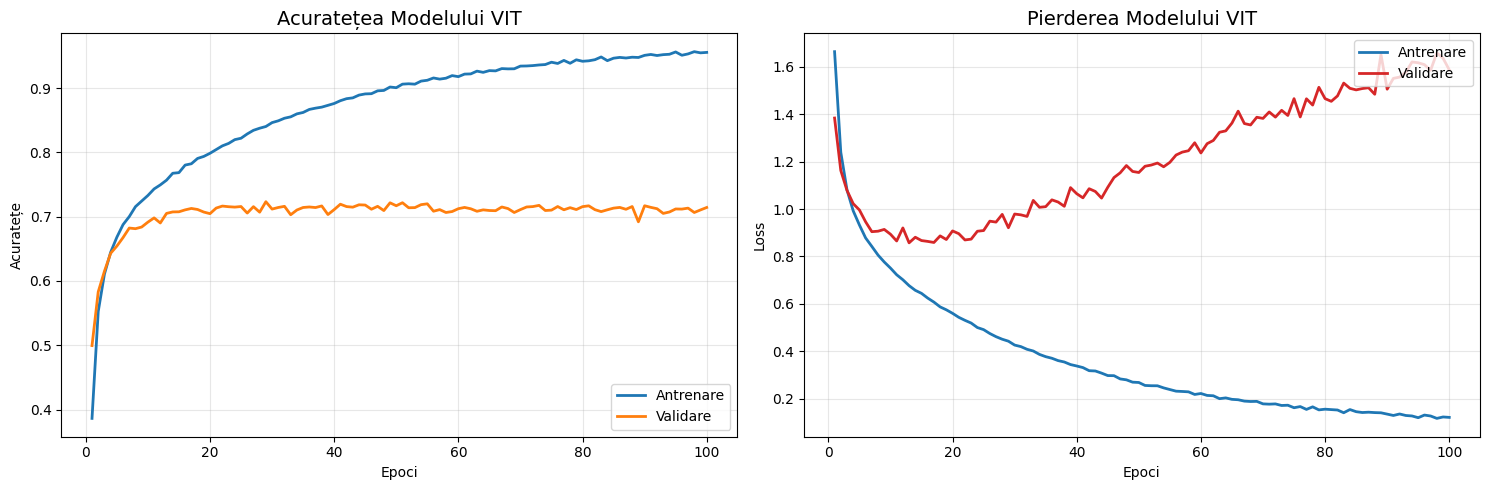

<Figure size 640x480 with 0 Axes>

In [64]:
import matplotlib.pyplot as plt
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Grafic pentru Acuratețe
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Antrenare', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validare', color='#ff7f0e', linewidth=2)
    plt.title('Acuratețea Modelului VIT', fontsize=14)
    plt.xlabel('Epoci')
    plt.ylabel('Acuratețe')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Grafic pentru Pierdere (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Antrenare', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validare', color='#d62728', linewidth=2)
    plt.title('Pierderea Modelului VIT', fontsize=14)
    plt.xlabel('Epoci')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.savefig('grafic_antrenare_vit.png')

# Apelează funcția după ce fit() s-a terminat
plot_training_history(history_vit)

## LB-CNN 
### https://github.com/AndreaMattiaGaravagno/ColabNAS

In [66]:
def create_lb_cnn_nas(params):
    # Extragere hiperparametri din dictionarul Optuna
    filtre = [params['f1'], params['f2'], params['f3']]
    nl = params['nl']
    convs = params['convs']
    flat_type = params['flat']

    csize = 3
    psize = 2
    stride = 2
    pad = 'same'

    model = keras.Sequential()
    model.add(layers.Input(shape=INPUT_SHAPE))
    # if SELECTED_DATASET == "cifar10":
    #     model.add(get_augmentation_layers())



   # --- LAYER 1 ---
    # Folosim Conv2D standard pentru primul strat pentru a procesa corect culorile RGB
    # Majoritatea variantelor LB-CNN permit primului strat să fie antrenabil/standard
    model.add(layers.Conv2D(filters=filtre[0], kernel_size=csize, padding=pad, use_bias=False))
    model.add(layers.BatchNormalization()) # ESENȚIAL pentru CIFAR-10
    model.add(layers.Activation('relu'))
    
    if nl[0] > 1:
        for _ in range(nl[0]-1):
            model.add(layers.DepthwiseConv2D(kernel_size=csize, padding=pad, depth_multiplier=1, use_bias=False))
            model.add(layers.BatchNormalization())
            model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D(pool_size=(psize, psize), strides=(stride, stride), padding=pad))

    # --- LAYERS 2 & 3 ---
    for i in range(1, convs):
        model.add(layers.DepthwiseConv2D(kernel_size=csize, padding=pad, depth_multiplier=filtre[i], use_bias=False))
        model.add(layers.BatchNormalization()) # Stabilizează filtrele binare
        model.add(layers.Activation('relu'))
        
        if i < len(nl) and nl[i] > 1:
            for _ in range(nl[i]-1):
                model.add(layers.DepthwiseConv2D(kernel_size=csize, padding=pad, depth_multiplier=1, use_bias=False))
                model.add(layers.BatchNormalization())
                model.add(layers.Activation('relu'))
        
        model.add(layers.MaxPooling2D(pool_size=(psize, psize), strides=(stride, stride), padding=pad))

    # --- OUTPUT BLOCK ---
    if flat_type == 1:
        model.add(layers.Flatten())
    else:
        model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    # --- BINARIZARE GREUTĂȚI ---
    # Păstrăm logica de binarizare și înghețare (ADN-ul LB-CNN)
    for layer in model.layers:
        # Binarizăm doar straturile de convoluție (nu și BatchNormalization sau Dense)
        if isinstance(layer, (layers.DepthwiseConv2D, layers.Conv2D)):
            weights = layer.get_weights()
            if weights:
                binary_w = [np.sign(w - np.mean(w)) for w in weights]
                layer.set_weights(binary_w)
                # Primul strat îl putem lăsa antrenabil pentru CIFAR, sau False pentru LB-CNN pur
                layer.trainable = False 

    return model

## LB-CNN Optuna

In [71]:
def objective_lb_cnn(trial):
    # Definirea spațiului de căutare
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True) 
    batch_size = trial.suggest_categorical("batch_size",BATCH_SIZE)
    params = {
        'f1': trial.suggest_int('f1', 16, 64),   # Mai mic
        'f2': trial.suggest_int('f2', 32, 128),  # Mai mic
        'f3': trial.suggest_int('f3', 64, 256),  # Mai mic
        'convs': trial.suggest_int('convs', 1, 2), # Redu la 2 straturi pentru viteză
        'nl': (trial.suggest_int('nl1', 1, 2), trial.suggest_int('nl2', 1, 2)), 
        'flat': trial.suggest_categorical('flat', [0, 1])
    }
    
    model = create_lb_cnn_nas(params)
    
    # Compilare
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    # Acesta raportează acuratețea către Optuna după fiecare epocă
    pruning_callback = optuna.integration.TFKerasPruningCallback(trial, "val_accuracy")
    
    # Antrenare rapidă (Proxy Task)
    try:
        history = model.fit(
            x_train, y_train,
            validation_split=0.1, 
            epochs=10,
            batch_size=batch_size,
            callbacks=[pruning_callback],
            verbose=0
        )
        val_acc = max(history.history['val_accuracy'])
    except Exception as e:
        raise optuna.exceptions.TrialPruned()

    # Calculăm scorul penalizând complexitatea
    num_params = model.count_params()
    return val_acc - (num_params * 1e-7)

# 1. Pornire Optuna
start_time_lb_cnn_optuna = time.perf_counter()
study_lb_cnn = optuna.create_study(direction="maximize")
study_lb_cnn.optimize(objective_lb_cnn, n_trials=NUM_TRIALS)
end_time_lb_cnn_optuna = time.perf_counter()

time_lb_optuna = end_time_lb_cnn_optuna - start_time_lb_cnn_optuna

print("--- Rezultate NAS ---")

print(f"Cea mai buna acuratete: {study_lb_cnn.best_value:.4f}")
print(f"Cei mai buni paramatri gasiti: {study_lb_cnn.best_params}")
print(f'Timpul necesar cautarii: {(time_lb_optuna/60):.2f}min')

best_params_lb_cnn = study_lb_cnn.best_params
for key, value in best_params_lb_cnn .items():
    print(f'{key} : {value}')


[I 2026-05-19 21:50:00,681] A new study created in memory with name: no-name-bacf8261-fa01-4f9f-83ca-583d1d6e2578
[I 2026-05-19 21:50:22,968] Trial 0 finished with value: 0.5121750235557556 and parameters: {'lr': 0.007815600912356878, 'batch_size': 64, 'f1': 60, 'f2': 108, 'f3': 241, 'convs': 1, 'nl1': 2, 'nl2': 1, 'flat': 1}. Best is trial 0 with value: 0.5121750235557556.
[I 2026-05-19 21:52:51,946] Trial 1 finished with value: 0.5293317275611877 and parameters: {'lr': 0.0002724249794588833, 'batch_size': 128, 'f1': 63, 'f2': 40, 'f3': 133, 'convs': 2, 'nl1': 1, 'nl2': 2, 'flat': 0}. Best is trial 1 with value: 0.5293317275611877.
[I 2026-05-19 21:53:14,946] Trial 2 finished with value: 0.5905414576972962 and parameters: {'lr': 0.004101685532590674, 'batch_size': 64, 'f1': 44, 'f2': 114, 'f3': 255, 'convs': 1, 'nl1': 2, 'nl2': 1, 'flat': 1}. Best is trial 2 with value: 0.5905414576972962.
[I 2026-05-19 21:55:37,385] Trial 3 finished with value: -0.15379009443292618 and parameters: {'

--- Rezultate NAS ---
Cea mai buna acuratete: 0.6186
Cei mai buni paramatri gasiti: {'lr': 0.0008214273784517787, 'batch_size': 32, 'f1': 36, 'f2': 98, 'f3': 96, 'convs': 1, 'nl1': 2, 'nl2': 1, 'flat': 1}
Timpul necesar cautarii: 21.72min
lr : 0.0008214273784517787
batch_size : 32
f1 : 36
f2 : 98
f3 : 96
convs : 1
nl1 : 2
nl2 : 1
flat : 1


### Vizualizarea procesului de cautare

In [72]:
# # Afișează evoluția scorului
fig = vis.plot_optimization_history(study_lb_cnn)
fig.show()

# # Vezi care parametri contează cel mai mult
# vis.plot_param_importances(study_lb_cnn)

# # Vizualizează corelațiile dintre parametri
# vis.plot_parallel_coordinate(study_lb_cnn)

In [73]:
final_params = {
    'f1': best_params_lb_cnn['f1'], 'f2': best_params_lb_cnn['f2'], 'f3': best_params_lb_cnn['f3'],
    'convs': best_params_lb_cnn['convs'],
    'nl': (best_params_lb_cnn['nl1'], best_params_lb_cnn['nl2']),
    'flat': best_params_lb_cnn['flat']
}

model_lb = create_lb_cnn_nas(final_params)
model_lb.summary()

Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_223 (Conv2D)             │ (None, 32, 32, 36)     │           972 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_329         │ (None, 32, 32, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_189 (Activation)     │ (None, 32, 32, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_549            │ (None, 32, 32, 36)     │           324 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_330         │ (None, 32, 32, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_190 (Activation)     │ (None, 32, 32, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_693               │ (None, 16, 16, 36)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_917 (Dense)               │ (None, 10)             │        92,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,754 (366.23 KB)

 Trainable params: 92,314 (360.60 KB)

 Non-trainable params: 1,440 (5.62 KB)

In [74]:
# Reconstrucție Model Optim

model_lb.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params_lb_cnn.get('lr', 1e-3)),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#  Antrenare completă
print("\nÎncepe antrenarea finală a modelului LB-CNN...")

checkpoint_filepath_lb_cnn = 'best_lb_cnn_model.keras'
model_checkpoint_callback_lb_cnn = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath_lb_cnn,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)



history_lb = model_lb.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=best_params_lb_cnn['batch_size'],
    callbacks=[model_checkpoint_callback_lb_cnn],
)

# Evaluare finală
print("Evaluzarea celui mai bun model pe setul de test:")
model_lb.load_weights(checkpoint_filepath_lb_cnn)
loss, acc = model_lb.evaluate(x_test, y_test)
print(f"Acuratețe finală pe setul de test: {acc*100:.2f}%")



Începe antrenarea finală a modelului LB-CNN...
Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4403 - loss: 1.8104 - val_accuracy: 0.5833 - val_loss: 1.2517
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6221 - loss: 1.1061 - val_accuracy: 0.5959 - val_loss: 1.2376
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6685 - loss: 0.9638 - val_accuracy: 0.6167 - val_loss: 1.1458
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6973 - loss: 0.8820 - val_accuracy: 0.6078 - val_loss: 1.1997
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7148 - loss: 0.8279 - val_accuracy: 0.6121 - val_loss: 1.2052
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7344 - loss: 0.7734 - val_accuracy: 0.6100 - val_loss: 1.2035
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7538 - loss: 0.7204 - val_accuracy: 0.6147 - val_loss: 1.2238
Epoch 8/100
1563/1563 ━━━━━━━━━━━━

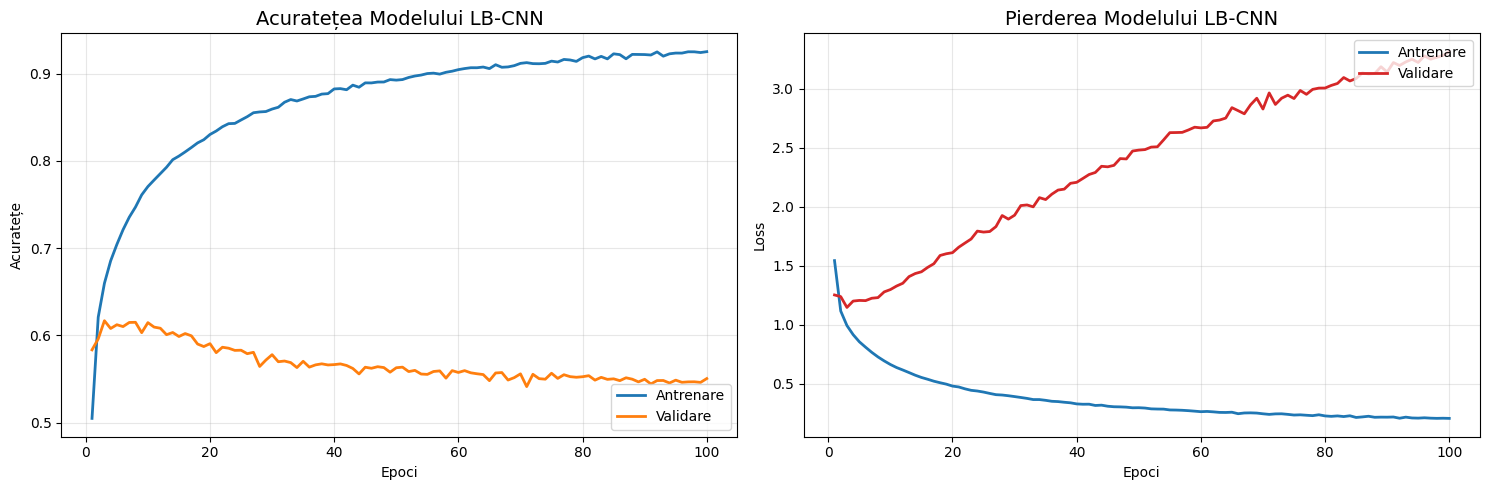

<Figure size 640x480 with 0 Axes>

In [75]:
import matplotlib.pyplot as plt
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Grafic pentru Acuratețe
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Antrenare', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validare', color='#ff7f0e', linewidth=2)
    plt.title('Acuratețea Modelului LB-CNN', fontsize=14)
    plt.xlabel('Epoci')
    plt.ylabel('Acuratețe')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Grafic pentru Pierdere (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Antrenare', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validare', color='#d62728', linewidth=2)
    plt.title('Pierderea Modelului LB-CNN', fontsize=14)
    plt.xlabel('Epoci')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.savefig('grafic_antrenare_lb_cnn.png')

# Apelează funcția după ce fit() s-a terminat
plot_training_history(history_lb)